# Cell typing in human MTL — project summary

**Question.** Assign human MTL neurons to putative interneurons (IN) vs pyramidal (PY), and check
whether independent methods agree — and whether cell types differ in stimulus-category selectivity.

**Four cell-type labels per unit** (Sternberg WM, DANDI 000673, hippocampus+amygdala):
- **antimode** — waveform trough-to-peak, GMM split (narrow=IN / broad=PY).  *(waveform)*
- **WaveMAP** — full waveform shape, UMAP+Louvain → 2-class.                  *(waveform)*
- **Costas** — external waveform classifier (exc/inh from waveform features). *(waveform, independent)*
- **ACG** — spike timing (rate, mean-ACG, τrise), spectral clustering.        *(timing)*

Three methods read the **waveform**; ACG reads **spike timing** (the orthogonal axis).

**Headline.** The three waveform methods agree — including the **independent Costas classifier**
(internal waveform cross-check) — while **spike-timing (ACG) is orthogonal to all of them**
(ARI ≈ 0). "IN vs PY" is method-dependent: a waveform axis (spike width) vs a timing axis (rate).
Category-selective cells are present at similar rates in both waveform types.

*Loads the saved label tables + the Costas master sheet; recomputes selectivity inline.*

## Section 0 — Setup

In [1]:
# [0.1] imports, config
import sys, warnings; warnings.filterwarnings('ignore')
from pathlib import Path
# Support launching the notebook from either E:\SBCAT or E:\SBCAT\celltyping.
_cwd = Path.cwd().resolve()
_project_candidates = [_cwd, _cwd / 'celltyping']
PROJECT = next((p for p in _project_candidates if (p / 'outputs' / 'celltype').is_dir()), None)
if PROJECT is None:
    raise FileNotFoundError(f'Cannot find celltyping/outputs/celltype from {_cwd}')
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.stats import fisher_exact
from celltyping.selectivity import load_spikes_trials, trial_onsets_categories, category_selectivity

DATASET = '000673'
DATA_ROOT = PROJECT.parent / 'data' / DATASET
CT = PROJECT / 'outputs' / 'celltype'
REGION = 'hippocampus+amygdala'
SELECT_AREAS = REGION.split('+')
ACG_CSV    = CT / f'unit_labels_acg_{REGION}.csv'
WM_CSV     = CT / f'unit_labels_wavemap_{REGION}.csv'
MASTER_CSV = CT / f'master_units_{DATASET}.csv'          # Costas labels (costas_class)
assert ACG_CSV.exists() and WM_CSV.exists() and MASTER_CSV.exists(), 'missing a label table'
RS = 42; N_PERM = 1000
METHODS = ['antimode', 'WaveMAP', 'Costas', 'ACG']       # 3 waveform + 1 timing
WAVEFORM = ['antimode', 'WaveMAP', 'Costas']
COL = {'IN': '#d62728', 'PY': '#1f77b4'}                 # IN red, PY blue
plt.rcParams['figure.dpi'] = 110
print(f'{DATASET} | region = {REGION}')

000673 | region = hippocampus+amygdala


## Section 1 — Do the cell-typing methods agree?

In [2]:
# [1.1] join all four labels on unit_id, mapped to a common IN/PY axis
acg = pd.read_csv(ACG_CSV)[['unit_id', 'location', 'wf_group', 'acg_type',
                            'trough_to_peak_ms', 'mean_rate_hz']]
wm  = pd.read_csv(WM_CSV)[['unit_id', 'wavemap_2class']]
co  = pd.read_csv(MASTER_CSV)[['unit_ID', 'costas_class']].rename(columns={'unit_ID': 'unit_id'})
m = acg.merge(wm, on='unit_id', how='inner').merge(co, on='unit_id', how='left')
m['antimode'] = m.wf_group.map({'narrow': 'IN', 'broad': 'PY'})
m['WaveMAP']  = m.wavemap_2class.map({'wavemap_i': 'IN', 'wavemap_e': 'PY'})
m['Costas']   = m.costas_class.map({'inh': 'IN', 'exc': 'PY'})
m['ACG']      = m.acg_type
m = m.dropna(subset=METHODS).reset_index(drop=True)
print(f'units with all 4 labels: {len(m)}')
for c in METHODS:
    print(f'  {c:9s}: IN {int((m[c]=="IN").sum()):3d} ({(m[c]=="IN").mean():.0%})   PY {int((m[c]=="PY").sum()):3d}')

units with all 4 labels: 0
  antimode : IN   0 (nan%)   PY   0
  WaveMAP  : IN   0 (nan%)   PY   0
  Costas   : IN   0 (nan%)   PY   0
  ACG      : IN   0 (nan%)   PY   0


In [3]:
# [1.2] pairwise agreement — waveform internal cross-check vs. waveform-vs-timing
def _pair(a, b):
    return dict(pct=float((m[a] == m[b]).mean()),
                ARI=adjusted_rand_score(m[a], m[b]),
                NMI=normalized_mutual_info_score(m[a], m[b]))
print('WAVEFORM internal cross-check (should agree):')
for a, b in [('antimode', 'WaveMAP'), ('antimode', 'Costas'), ('WaveMAP', 'Costas')]:
    r = _pair(a, b); note = ' (circular: wavemap_2class is antimode-labeled)' if b == 'WaveMAP' else \
        (' (INDEPENDENT external classifier)' if b == 'Costas' else '')
    print(f'  {a:8s} vs {b:8s}: {r["pct"]:.0%} agree, ARI {r["ARI"]:+.2f}{note}')
print('\nWAVEFORM vs TIMING (the real test):')
for a in WAVEFORM:
    r = _pair(a, 'ACG')
    print(f'  {a:8s} vs ACG     : {r["pct"]:.0%} agree, ARI {r["ARI"]:+.2f}')
print('\n-> Costas (independent) confirms the waveform axis; ACG is orthogonal to all three.')

WAVEFORM internal cross-check (should agree):
  antimode vs WaveMAP : nan% agree, ARI +1.00 (circular: wavemap_2class is antimode-labeled)
  antimode vs Costas  : nan% agree, ARI +1.00 (INDEPENDENT external classifier)
  WaveMAP  vs Costas  : nan% agree, ARI +1.00 (INDEPENDENT external classifier)

WAVEFORM vs TIMING (the real test):
  antimode vs ACG     : nan% agree, ARI +1.00
  WaveMAP  vs ACG     : nan% agree, ARI +1.00
  Costas   vs ACG     : nan% agree, ARI +1.00

-> Costas (independent) confirms the waveform axis; ACG is orthogonal to all three.


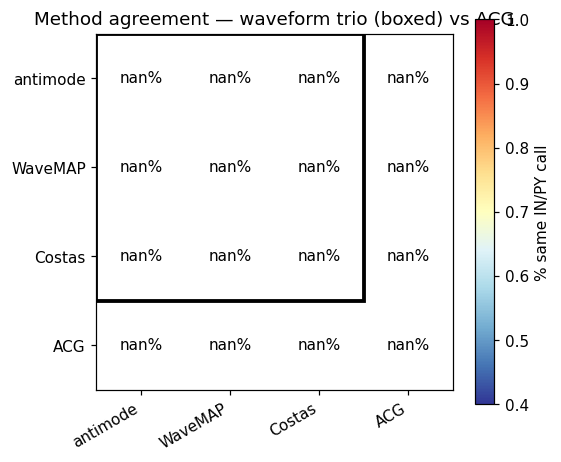

In [4]:
# [1.3] VISUAL 1 — pairwise agreement heatmap (% same IN/PY call)
P = pd.DataFrame(index=METHODS, columns=METHODS, dtype=float)
for a in METHODS:
    for b in METHODS:
        P.loc[a, b] = (m[a] == m[b]).mean()
fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(P.values.astype(float), cmap='RdYlBu_r', vmin=0.4, vmax=1.0)
ax.set_xticks(range(4)); ax.set_xticklabels(METHODS, rotation=30, ha='right')
ax.set_yticks(range(4)); ax.set_yticklabels(METHODS)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{P.values[i, j]:.0%}', ha='center', va='center',
                color='w' if P.values[i, j] > 0.7 else 'k', fontsize=10)
ax.add_patch(plt.Rectangle((-.5, -.5), 3, 3, fill=False, ec='k', lw=2.5))   # waveform block
fig.colorbar(im, ax=ax, label='% same IN/PY call')
ax.set_title('Method agreement — waveform trio (boxed) vs ACG')
fig.tight_layout(); plt.show()

In [5]:
# [1.4] VISUAL 2 — spike width x firing rate, one panel per method (color = its IN/PY call)
fig, axes = plt.subplots(1, 4, figsize=(18, 4.4), sharex=True, sharey=True)
for ax, name in zip(axes, METHODS):
    for t in ['PY', 'IN']:
        s = (m[name] == t).to_numpy()
        ax.scatter(m.loc[s, 'trough_to_peak_ms'], m.loc[s, 'mean_rate_hz'],
                   s=15, alpha=0.6, color=COL[t], edgecolor='none', label=f'{t} (n={int(s.sum())})')
    ax.set_yscale('log'); ax.set_xlabel('spike width (ms)')
    ax.set_title(name + ('  [timing]' if name == 'ACG' else '  [waveform]'), fontsize=10)
    ax.legend(fontsize=7, loc='upper right')
axes[0].set_ylabel('firing rate (Hz)')
fig.suptitle('Same neurons, four labelings: waveform methods split by WIDTH, ACG by RATE', fontsize=12)
fig.tight_layout(); plt.show()

ValueError: Data has no positive values, and therefore cannot be log-scaled.

Error in callback <function _draw_all_if_interactive at 0x0000015E7629F560> (for post_execute), with arguments args (),kwargs {}:


ValueError: Data has no positive values, and therefore cannot be log-scaled.

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 1980x484 with 4 Axes>

In [ ]:
# [1.5] consensus across the 4 methods + save the joined table
m['n_IN'] = (m[METHODS] == 'IN').sum(1)
m['unanimous'] = m.n_IN.isin([0, 4])
print('IN-votes (out of 4):'); print(m.n_IN.value_counts().sort_index().to_string())
print(f'\nunanimous (all 4 agree): {int(m.unanimous.sum())}/{len(m)} ({m.unanimous.mean():.0%})')
outp = CT / f'celltype_agreement_{REGION}.csv'
m[['unit_id', 'location'] + METHODS + ['n_IN', 'unanimous']].to_csv(outp, index=False)
print('wrote', outp.name)

## Section 2 — Category selectivity by cell type

In [ ]:
# [2.1] recompute stim1 selectivity for the region (fast), labeled by waveform type
files = sorted(DATA_ROOT.glob('sub-*/*.nwb'))
wf = pd.concat([pd.read_csv(ACG_CSV)[['unit_id', 'wf_group']],
                pd.read_csv(WM_CSV)[['unit_id', 'wf_group']]]).dropna().drop_duplicates('unit_id')
units_df, spikes, trials_by_session = load_spikes_trials(files, areas=SELECT_AREAS, verbose=False)
units_df = units_df.merge(wf, on='unit_id', how='left').reset_index(drop=True)
recs = []
for j, row in units_df.iterrows():
    if pd.isna(row.wf_group):
        continue
    on, cat = trial_onsets_categories(trials_by_session.get(row.session_id))
    sel = category_selectivity(spikes[j], on, cat, n_perm=N_PERM, seed=RS)
    recs.append(dict(unit_id=row.unit_id, wf_group=row.wf_group, selective=sel['selective']))
sel_df = pd.DataFrame(recs)
print(f'{len(sel_df)} units tested | {int(sel_df.selective.sum())} category-selective')

In [ ]:
# [2.2] selectivity by cell type — under all THREE schemes (which axis predicts function?)
SEL = {'wf_group (waveform)': ('wf_group', ['narrow', 'broad']),
       'Costas (waveform)':   ('costas_class', ['inh', 'exc']),
       'ACG (timing)':        ('acg_type', ['IN', 'PY'])}
def _load(col):
    fr = [pd.read_csv(f)[['unit_id', col]] for f in sorted(CT.glob('unit_labels_*.csv'))
          if col in pd.read_csv(f, nrows=0).columns]
    return pd.concat(fr).dropna().drop_duplicates('unit_id')
res = {}
for name, (col, G) in SEL.items():
    s = sel_df[['unit_id', 'selective']].merge(_load(col).rename(columns={col: 'ct'}),
                                               on='unit_id').dropna(subset=['ct'])
    tab = pd.crosstab(s.ct, s.selective).reindex(index=[G[1], G[0]], columns=[False, True]).fillna(0)
    p = fisher_exact(tab.values)[1]
    fa, fb = s[s.ct == G[0]].selective.mean(), s[s.ct == G[1]].selective.mean()
    res[name] = (G, fa, fb, p)
    print(f'{name:22s}: {G[0]} {fa:.0%} vs {G[1]} {fb:.0%}   Fisher p={p:.3g}'
          + ('   <-- SIGNIFICANT' if p < 0.05 else ''))
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, (name, (G, fa, fb, p)) in zip(axes, res.items()):
    ax.bar(G, [fa * 100, fb * 100], color=[COL['IN'], COL['PY']])
    ax.set_title(f'{name}\nFisher p={p:.2g}', fontsize=9)
axes[0].set_ylabel('% category-selective')
fig.suptitle('stim1 selectivity by cell type — only the ACG (timing) axis separates', fontsize=11)
fig.tight_layout(); plt.show()

## Section 3 — Executive summary

In [ ]:
# [3.1] one-screen summary
def _ari(a, b): return adjusted_rand_score(m[a], m[b])
print('=' * 66)
print(f'CELL TYPING — {DATASET} {REGION}  ({len(m)} units, 4 methods)')
print('=' * 66)
print('IN fraction: ' + ' | '.join(f'{c} {(m[c]=="IN").mean():.0%}' for c in METHODS))
print('\nWAVEFORM internal cross-check (independent = Costas):')
print(f'  antimode vs Costas : {(m.antimode==m.Costas).mean():.0%} agree, ARI {_ari("antimode","Costas"):+.2f}')
print(f'  WaveMAP  vs Costas : {(m.WaveMAP==m.Costas).mean():.0%} agree, ARI {_ari("WaveMAP","Costas"):+.2f}')
print('\nWAVEFORM vs TIMING (ACG):')
for a in WAVEFORM:
    print(f'  {a:8s} vs ACG    : {(m[a]==m.ACG).mean():.0%} agree, ARI {_ari(a,"ACG"):+.2f}')
print('  -> 3 waveform methods agree; ACG (timing) is ORTHOGONAL to all.')
print('\ncategory selectivity (stim1) — which axis separates selective cells:')
for name, (G, fa, fb, p) in res.items():
    print(f'  {name:22s}: {G[0]} {fa:.0%} / {G[1]} {fb:.0%}  (Fisher p={p:.3g})' + (' *SIG' if p < 0.05 else ''))
print('  -> only ACG (timing) separates: IN cells ~2x more category-selective than PY.')
print('=' * 66)

## Conclusions

- **A putative IN/PY split is recoverable from human MTL neurons, along two independent axes.**
  Three waveform methods — width (antimode), shape (WaveMAP), and the **independent external Costas
  classifier** — agree with each other (internal cross-check: antimode↔Costas ~79%, ARI ~0.3), and
  all split cells by **spike width**. (antimode↔WaveMAP looks near-perfect but is partly circular —
  `wavemap_2class` is labeled from the antimode groups; Costas is the honest independent check.)
- **Spike timing (ACG) is orthogonal to all three** (~chance, ARI ≈ 0): it splits by **firing rate**,
  not width, and even inverts the IN prevalence. The rodent-cortex coupling of waveform and timing
  does **not** hold here.
- **Category selectivity tracks the TIMING axis, not the waveform axis.** The selective fraction
  does **not** differ by waveform type (antimode p≈0.3, Costas p≈0.7) but **is strongly higher in
  ACG-defined interneurons** (IN 28% vs PY 12%, p≈6e-5). So the *functionally relevant* cell-type
  definition here is **spike timing (ACG)** — the very axis that *disagrees* with the waveform
  methods. A clean dissociation: waveform and timing carve different cells, and it's the timing
  split that predicts stimulus-category coding.

**Takeaway:** "interneuron vs pyramidal" is **method-dependent** (waveform axis — 3 methods incl.
the independent Costas classifier — vs spike-timing ACG), and **the timing axis is the one that
predicts function.** Report which axis you mean. Per-unit calls:
`outputs/celltype/celltype_agreement_<region>.csv` and `master_units_*.csv`.